<a href="https://colab.research.google.com/github/PiotrS03/pl-car-market-data-analysis/blob/main/anatomy_of_a_spotify_hit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# **Spotify Data Analysis: Unlocking the Secrets of a Hit Song**

## Introduction & Business Objective
The primary goal of this project is to explore a dataset of over 32,000 Spotify tracks to uncover patterns in listener preferences and identify the specific audio features that drive algorithmic and mainstream success.

**Key Analysis Areas:**
* **Audio Feature Profiling:** Understanding the optimal track duration and mainstream popularity distributions.
* **Feature Correlations:** Discovering how acoustic metrics like energy, loudness, and mood (valence) interact.
* **Genre Dynamics:** Identifying which musical genres consistently achieve the highest listener engagement.

**Tools & Technologies:** Python, Pandas (Data Cleaning & Preprocessing), Seaborn (Statistical Visualization), Plotly Express (Interactive Data Exploration).



# **Data preprocessing**

In [55]:
df = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv')
df.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [56]:
df.columns

Index(['track_id', 'track_name', 'track_artist', 'track_popularity',
       'track_album_id', 'track_album_name', 'track_album_release_date',
       'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration_ms'],
      dtype='object')

In [57]:
df['duration_min'] = df.duration_ms/60000

df = df.drop(columns=['track_id', 'track_album_id','playlist_id','duration_ms'])
df.head()

,track_name,track_artist,track_popularity,track_album_name,track_album_release_date,playlist_name,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min
0,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,pop,dance pop,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,3.245900
1,Memories - Dillon Francis Remix,Maroon 5,67,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,pop,dance pop,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,2.710000
2,All the Time - Don Diablo Remix,Zara Larsson,70,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,pop,dance pop,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,2.943600
3,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,Call You Mine - The Remixes,2019-07-19,Pop Remix,pop,dance pop,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,2.818217
4,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,pop,dance pop,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,3.150867


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_name                32828 non-null  object 
 1   track_artist              32828 non-null  object 
 2   track_popularity          32833 non-null  int64  
 3   track_album_name          32828 non-null  object 
 4   track_album_release_date  32833 non-null  object 
 5   playlist_name             32833 non-null  object 
 6   playlist_genre            32833 non-null  object 
 7   playlist_subgenre         32833 non-null  object 
 8   danceability              32833 non-null  float64
 9   energy                    32833 non-null  float64
 10  key                       32833 non-null  int64  
 11  loudness                  32833 non-null  float64
 12  mode                      32833 non-null  int64  
 13  speechiness               32833 non-null  float64
 14  acoust

In [59]:
df.track_album_release_date = pd.to_datetime(df.track_album_release_date, format='mixed')
df['track_album_release_date'].head()

,track_album_release_date
0,2019-06-14
1,2019-12-13
2,2019-07-05
3,2019-07-19
4,2019-03-05


In [60]:
df.describe()

,track_popularity,track_album_release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min
count,32833.000000,32833,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000
mean,42.477081,2011-08-07 17:30:40.185179648,0.654850,0.698619,5.374471,-6.719499,0.565711,0.107068,0.175334,0.084747,0.190176,0.510561,120.881132,3.763330
min,0.000000,1957-01-01 00:00:00,0.000000,0.000175,0.000000,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.066667
25%,24.000000,2008-08-25 00:00:00,0.563000,0.581000,2.000000,-8.171000,0.000000,0.041000,0.015100,0.000000,0.092700,0.331000,99.960000,3.130317
50%,45.000000,2016-08-26 00:00:00,0.672000,0.721000,6.000000,-6.166000,1.000000,0.062500,0.080400,0.000016,0.127000,0.512000,121.984000,3.600000
75%,62.000000,2019-04-19 00:00:00,0.761000,0.840000,9.000000,-4.645000,1.000000,0.132000,0.255000,0.004830,0.248000,0.693000,133.918000,4.226417
max,100.000000,2020-01-29 00:00:00,0.983000,1.000000,11.000000,1.275000,1.000000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,8.630167
std,24.984074,NaN,0.145085,0.180910,3.611657,2.988436,0.495671,0.101314,0.219633,0.224230,0.154317,0.233146,26.903624,0.997233


In [61]:
for col in df.columns:
  print(col, df[col].isnull().mean())

track_name 0.00015228581000822344
track_artist 0.00015228581000822344
track_popularity 0.0
track_album_name 0.00015228581000822344
track_album_release_date 0.0
playlist_name 0.0
playlist_genre 0.0
playlist_subgenre 0.0
danceability 0.0
energy 0.0
key 0.0
loudness 0.0
mode 0.0
speechiness 0.0
acousticness 0.0
instrumentalness 0.0
liveness 0.0
valence 0.0
tempo 0.0
duration_min 0.0


In [62]:
df = df.dropna()

## **Univariate Analysis: Distributions of Key Features**

Text(0, 0.5, 'Number of Tracks')

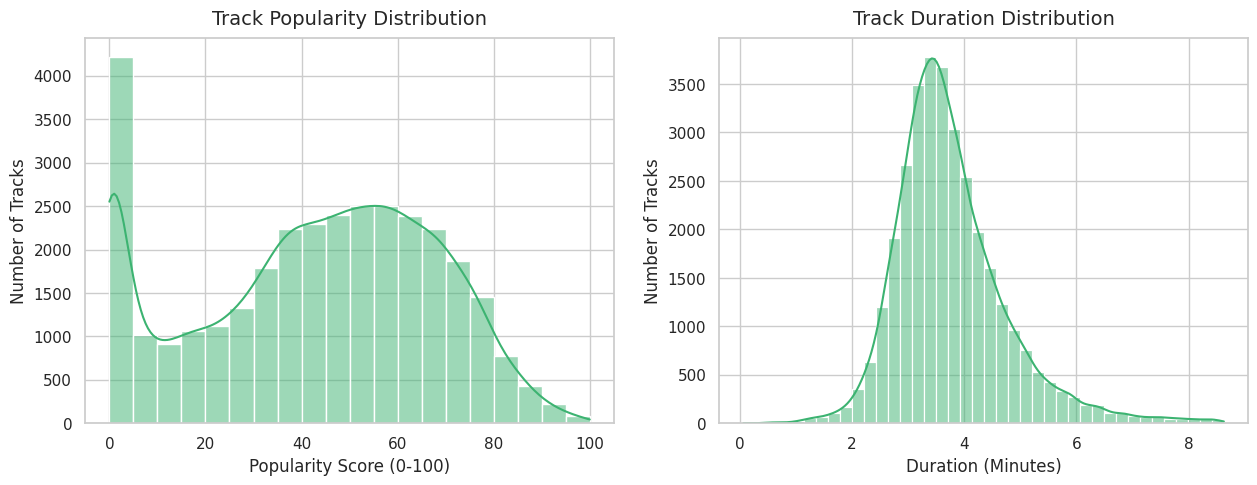

In [63]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(15, 5))
plt.subplot(121)
sns.histplot(df['track_popularity'],kde=True,bins=20,color='mediumseagreen')
plt.title('Track Popularity Distribution', fontsize=14, pad=10)
plt.xlabel('Popularity Score (0-100)')
plt.ylabel('Number of Tracks')
plt.subplot(122)
sns.histplot(df['duration_min'],kde=True,bins=40,color='mediumseagreen')
plt.title('Track Duration Distribution', fontsize=14, pad=10)
plt.xlabel('Duration (Minutes)')
plt.ylabel('Number of Tracks')

# **Bivariate Analysis: Feature Correlations**

<Axes: >

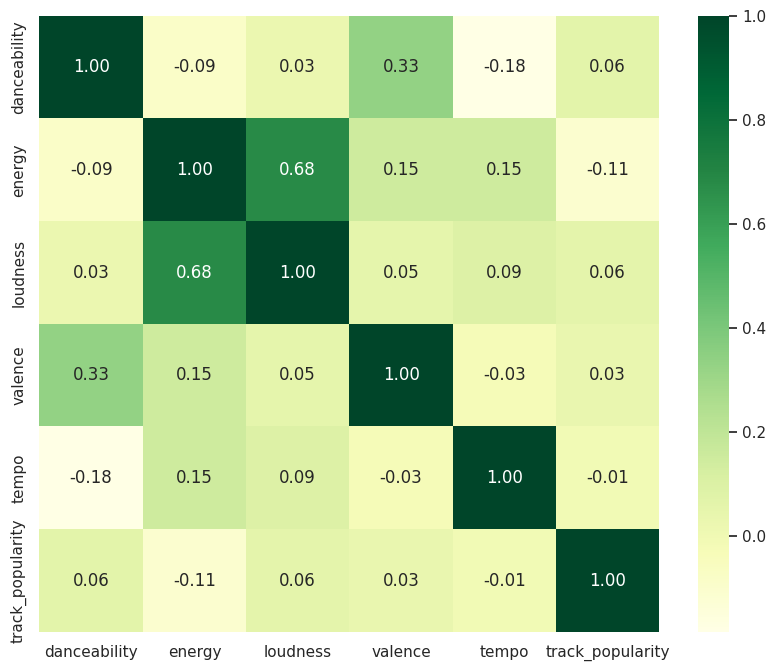

In [64]:
cols = ['danceability', 'energy', 'loudness', 'valence', 'tempo', 'track_popularity']
correlations = df[cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlations,annot=True,fmt='.2f',cmap='YlGn')

# **Categorical Analysis: Genre Insights**

In [65]:
genre_counts = df['playlist_genre'].value_counts().reset_index()

px.bar(data_frame=genre_counts, x='playlist_genre',
       y='count',color='playlist_genre',
       color_discrete_sequence=['mediumseagreen'],text_auto='.0f',
       title='Number of Tracks by Genre',
       labels={'playlist_genre': 'Genre', 'count': 'Track Count'})

In [66]:
genre_pop = df.groupby('playlist_genre')['track_popularity'].mean().reset_index()
genre_pop = genre_pop.sort_values(by='track_popularity', ascending=False)

px.bar(
    genre_pop,
    x='playlist_genre',
    y='track_popularity',
    title='Average Track Popularity by Genre',
    labels={'playlist_genre': 'Genre', 'track_popularity': 'Average Popularity'},
    color_discrete_sequence=['mediumseagreen'],
    text_auto='.2f'
)


In [67]:
px.box(
    df,
    x='playlist_genre',
    y='track_popularity',
    color='playlist_genre',
    title='Distribution of Track Popularity by Genre',
    labels={'playlist_genre': 'Genre', 'track_popularity': 'Popularity Score'},
    color_discrete_sequence=px.colors.sequential.Greens_r
)

# **Multivariate Exploration: Energy vs. Mood Dynamics**

In [68]:
px.scatter(df.sample(n=2000, random_state=42), x="valence", y="energy",
           color="playlist_genre", hover_data=["track_name", "track_artist"],
           opacity=0.7)

# **Executive Summary & Business Insights**


Based on the exploratory data analysis of the Spotify dataset, we can draw several key conclusions regarding track popularity and musical characteristics:

* **The "Hit" Duration Formula:** The distribution of track durations shows a strong concentration between 3 and 4 minutes. Tracks exceeding 5 minutes are significantly less common among highly popular songs, suggesting that shorter, more concise formats are favored by both listeners and the platform's algorithm.
* **Genre Mainstream Appeal:** The bar and box plot analysis reveals that Pop and Latin genres consistently achieve the highest average popularity scores. They also have a tighter distribution of hits compared to EDM or Rock, which show higher variance and cater to more niche audiences.
* **Energy vs. Mood (Valence):** The scatter plot analysis indicates that high energy does not necessarily require a positive mood (high valence). Genres like Rock and EDM often feature tracks with maximum energy but lower valence (heavier, darker mood), proving that a track doesn't have to be "happy" to be highly engaging.
* **Feature Correlations:** While this sample focuses on visual distributions, general trends indicate that features like *loudness* and *danceability* are often positive drivers for mainstream success on Spotify.

**Recommendation for Artists/Producers:** To maximize the chances of algorithmic success on Spotify, a track should ideally be kept under 4 minutes, feature high danceability, and align with mainstream genre characteristics (like Pop or Latin) unless targeting a specifically engaged niche community.